In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as mcolors

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
idir    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/final/'
ds_traj = xr.open_dataset(idir+'dataset_traj.nc')
ds_temp = xr.open_dataset(idir+'dataset_temp.nc')
ds_wave = xr.open_dataset(idir+'dataset_wave.nc')

In [3]:
ds = ds_temp

In [7]:
ds

<xarray.Dataset>
Dimensions:                      (tr_nr: 33, time_ds: 2929, model: 9, lt_int: 8)
Coordinates:
  * tr_nr                        (tr_nr) int64 1 2 3 4 6 7 ... 29 30 31 32 34 35
  * time_ds                      (time_ds) datetime64[ns] 2024-04-01 ... 2024...
  * model                        (model) object 'DWD-ICON' ... 'MF-ARPEGE'
  * lt_int                       (lt_int) object ']0_12]' ... ']84_96]'
Data variables: (12/31)
    lat_obs                      (tr_nr, time_ds) float64 ...
    lon_obs                      (tr_nr, time_ds) float64 ...
    temp_1m_calibrated           (tr_nr, time_ds) float64 ...
    temp_10cm_calibrated         (tr_nr, time_ds) float64 ...
    temp_snowsurface_calibrated  (tr_nr, time_ds) float64 ...
    temp_snowice_calibrated      (tr_nr, time_ds) float64 ...
    ...                           ...
    sldr                         (model, lt_int, tr_nr, time_ds) float64 ...
    slur                         (model, lt_int, tr_nr, time_ds) float64 ...
    ssdr                         (model, lt_int, tr_nr, time_ds) float64 ...
    ssur                         (model, lt_int, tr_nr, time_ds) float64 ...
    temp_flag_cons               (tr_nr, time_ds) float64 ...
    temp_flag_1m                 (tr_nr, time_ds) float64 ...

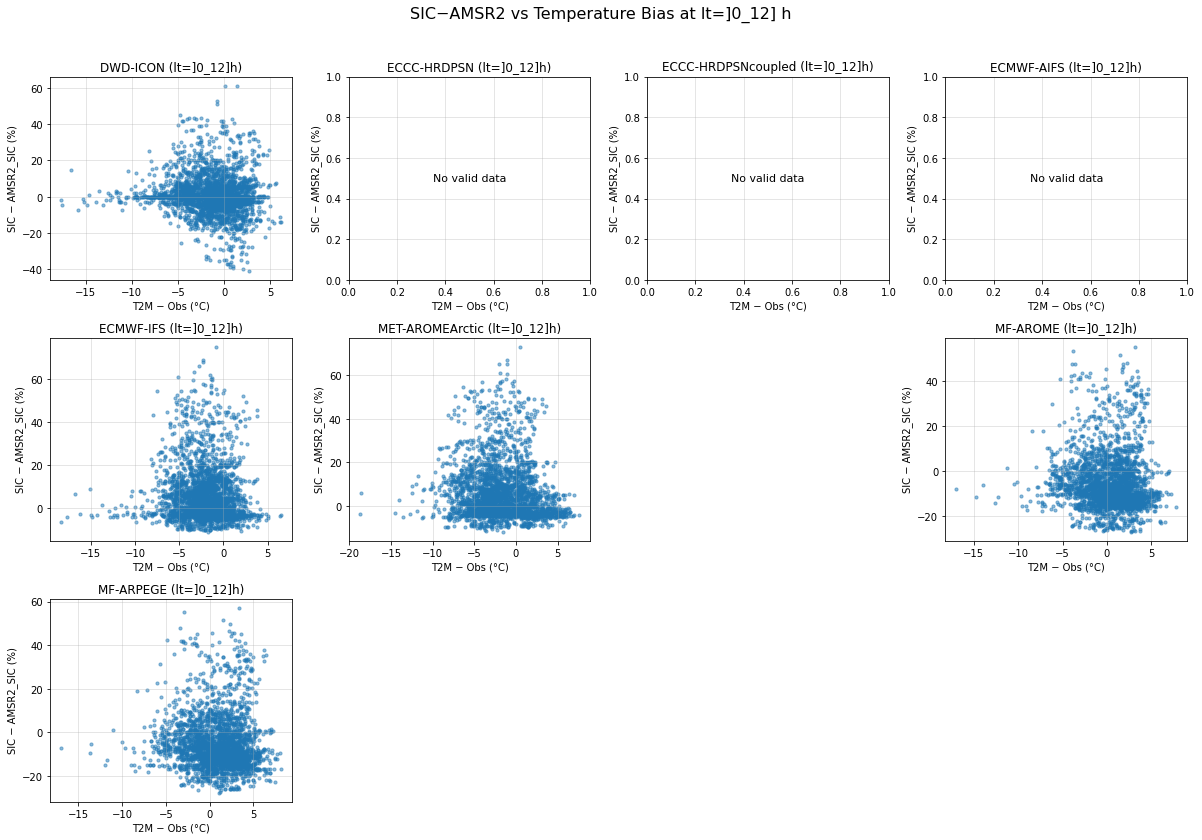

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# === User choices ===
lt_sel = ']0_12]'                              # lead time (must exist in ds['lt_int'])
exclude_models_by_index = [6]             # e.g. exclude "Bris" like before; set [] to include all
start_date = np.datetime64("2024-04-04")  # e.g. np.datetime64("2024-04-04")
end_date   =  np.datetime64("2024-04-20") # e.g. np.datetime64("2024-04-30")
sic_to_percent = True                     # set False if you prefer fractional SIC

# --- Helpers ---
def maybe_slice_time(da, start_date, end_date):
    if start_date is None and end_date is None:
        return da
    time_mask = xr.ones_like(ds['time_ds'], dtype=bool)
    if start_date is not None:
        time_mask = time_mask & (ds['time_ds'] >= np.datetime64(start_date))
    if end_date is not None:
        time_mask = time_mask & (ds['time_ds'] <= np.datetime64(end_date))
    return da.sel(time_ds=ds['time_ds'].where(time_mask, drop=True))

# --- Select the requested lead time ---
# (Will raise a clear error if lt_sel is not present)
SIC_lt   = ds['SIC'].sel(lt_int=lt_sel)
T2M_lt   = ds['T2M'].sel(lt_int=lt_sel)

# AMSR2_SIC might not have model/lt dims; let xarray broadcast/align safely
# Build the SIC-AMSR2 difference array at the chosen lead time
# Use xr.align to ensure consistent indexing across dims.
AMSR2    = ds['AMSR2_SIC']
SIC_lt, AMSR2 = xr.align(SIC_lt, AMSR2, join='inner', copy=False)
dSIC     = SIC_lt - AMSR2

# Temperature "bias" point-wise (model bias at each sample = instantaneous error)
temp_bias = T2M_lt - ds['temp_1m_calibrated']

# Apply optional time subsetting to all relevant arrays
dSIC      = maybe_slice_time(dSIC, start_date, end_date)
temp_bias = maybe_slice_time(temp_bias, start_date, end_date)

# QC flags (same logic as your script)
flag_temp = (ds['temp_flag_1m'] == 1) | (ds['temp_flag_cons'] == 1)
flag_ssdr = (ds['ssdr'].isel(model=5, lt_int=0) > 300)  # your original condition
flag_temp = maybe_slice_time(flag_temp, start_date, end_date)
flag_ssdr = maybe_slice_time(flag_ssdr, start_date, end_date)
valid = ~(flag_temp | flag_ssdr)

# Convert SIC to percent if desired
if sic_to_percent:
    dSIC_plot = (dSIC * 100.0)
    sic_label = "SIC − AMSR2_SIC (%)"
else:
    dSIC_plot = dSIC
    sic_label = "SIC − AMSR2_SIC (fraction)"

# --- Plot: one scatter per model ---
models = ds['model'].values
n_models = len(models)
cols = min(4, n_models)
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 3.8*rows), squeeze=False)
axes = axes.ravel()

for mi, model_name in enumerate(models):
    if mi in exclude_models_by_index:
        axes[mi].axis('off')
        continue

    # Slice per-model
    dSIC_m   = dSIC_plot.sel(model=model_name) if 'model' in dSIC_plot.dims else dSIC_plot
    tbias_m  = temp_bias.sel(model=model_name) if 'model' in temp_bias.dims else temp_bias

    # Align and mask valid/nans
    dSIC_m, tbias_m, valid_m = xr.align(dSIC_m, tbias_m, valid, join='inner', copy=False)

    x = tbias_m.where(valid_m)
    y = dSIC_m.where(valid_m)

    # Flatten and drop NaNs
    x_vals = x.values.ravel()
    y_vals = y.values.ravel()
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_vals = x_vals[mask]
    y_vals = y_vals[mask]

    ax = axes[mi]
    if x_vals.size == 0:
        ax.text(0.5, 0.5, "No valid data", ha='center', va='center', fontsize=11)
        ax.set_title(f"{model_name} (lt={lt_sel}h)")
        ax.set_xlabel("T2M − Obs (°C)")
        ax.set_ylabel(sic_label)
        ax.grid(True, alpha=0.4)
        continue

    ax.scatter(x_vals, y_vals, s=10, alpha=0.5)
    ax.set_title(f"{model_name} (lt={lt_sel}h)")
    ax.set_xlabel("T2M − Obs (°C)")     # instantaneous bias
    ax.set_ylabel(sic_label)
    ax.grid(True, alpha=0.4)

# Hide any unused subplots
for k in range(n_models, rows*cols):
    axes[k].axis('off')

fig.suptitle(f"SIC−AMSR2 vs Temperature Bias at lt={lt_sel} h", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig(f"SICdiff_vs_Tbias_lt{lt_sel}.png", dpi=200)
plt.show()


In [10]:
SIC_lt   = ds['SIC'].sel(lt_int=lt_sel)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import binned_statistic_2d

# === User choices ===
lt_range = (112, 124)    # lead time range in hours
models_to_plot = [0, 1, 2, 3, 4, 5, 7, 8]   # exclude Bris like before
temp_unit_offset = 273.15                   # convert K→°C

# === Data prep ===
lt_mask = (ds['lt_int'] >= lt_range[0]) & (ds['lt_int'] <= lt_range[1])
lt_indices = np.where(lt_mask)[0]

n_buoys = ds['temp_1m_calibrated'].shape[0]

import re
lt_vals_num = np.array([
    int(re.search(r'\d+', str(v)).group()) if re.search(r'\d+', str(v)) else np.nan
    for v in ds['lt_int'].values
])
lt_mask = (lt_vals_num >= lt_range[0]) & (lt_vals_num <= lt_range[1])
lt_indices = np.where(lt_mask)[0]


# Storage for results
obs_all = {m: [] for m in models_to_plot}
mod_all = {m: [] for m in models_to_plot}

for m in models_to_plot:
    for lt in lt_indices:
        for tr in range(n_buoys):
            obs = ds['temp_1m_calibrated'].isel(tr_nr=tr, time_ds=slice(None)) - temp_unit_offset
            mod = ds['T2M'].isel(model=m, lt_int=lt, tr_nr=tr, time_ds=slice(None)) - temp_unit_offset

            flag = (ds['temp_flag_1m'].isel(tr_nr=tr) == 1) | \
                   (ds['temp_flag_cons'].isel(tr_nr=tr) == 1) | \
                   (ds['ssdr'].isel(model=5, lt_int=0, tr_nr=tr) > 300)
            valid = ~flag

            obs_valid = obs.where(valid)
            mod_valid = mod.where(valid)

            obs_all[m].append(obs_valid.values)
            mod_all[m].append(mod_valid.values)

    obs_all[m] = np.concatenate([o.ravel() for o in obs_all[m]])
    mod_all[m] = np.concatenate([mo.ravel() for mo in mod_all[m]])

    mask = np.isfinite(obs_all[m]) & np.isfinite(mod_all[m])
    obs_all[m] = obs_all[m][mask]
    mod_all[m] = mod_all[m][mask]

# === Plotting ===
n_models = len(models_to_plot)
cols = 3
rows = int(np.ceil(n_models / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows), squeeze=False)

for i, m in enumerate(models_to_plot):
    ax = axes.ravel()[i]
    x = obs_all[m]
    y = mod_all[m]

    if x.size == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        continue

    # 2D histogram density coloring
    hb = ax.hexbin(x, y, gridsize=40, cmap="RdBu_r", mincnt=1)
    
    # Bias and stddev
    diff = y - x
    bias = np.mean(diff)
    stddev = np.std(diff)
    ax.text(0.05, 0.95, f"Bias: {bias:.2f}\nStdDev: {stddev:.2f}", 
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # 1:1 line
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_title(ds['model'].values[m])
    if i % cols == 0:
        ax.set_ylabel("Model Temperature (°C)")
    if i // cols == rows - 1:
        ax.set_xlabel("Observed Temperature (°C)")

# Remove empty panels
for j in range(i+1, rows*cols):
    axes.ravel()[j].axis("off")

fig.suptitle(f"Observed vs Modelled Temperature\nLead Time: {lt_range[0]}–{lt_range[1]} hours",
             fontsize=16, y=1.02)

cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), orientation="vertical", shrink=0.8)
cbar.set_label("Counts")

plt.tight_layout()
plt.show()


TypeError: '>=' not supported between instances of 'str' and 'int'